# BMEB W4020: Circuits in the Brain 2025 Fall Homework \#3 Handout
*Author:* Shashwat Shukla <shashwat.shukla@columbia.edu> Bruce Yi Bu <yb2520@columbia.edu>


*Based on Previous Work by:* Tingkai Liu, Mehmet Kerem Turkcan, Chung-Heng Yeh,
                  Konstantinos Psychas, Cong Han

Copyright 2012-2023 Shashwat Shukla, Bruce Yi Bu, Tingkai Liu and Aurel A. Lazar


# PROBLEM \#1 - $\delta$-insensitive TDM

The stimulus of a single-input single-output (SISO) TEM is modeled as
a bandlimited function of the form
$$
u(t)= \sum_{k=1}^{15} u(kT) \frac{\sin \Omega (t-kT)}{\Omega (t-kT)},
$$
where $\Omega = 2 \pi \cdot 25$ Hz and $T=\frac{\pi}{\Omega}$.

Note that here $f = 25Hz$ is the band of the signal; $T$ is not the '$\frac{1}{f}$' of the signal (it is not periodic) but rather then *Nyquist sampling interval*, satisfying sampling rate $\frac{1}{T}=\frac{\Omega}{\pi}$ being twice the bandwidth $f=\frac{\Omega}{2\pi}$.

Assume that the TEM describes an ASDM neuron, with parameters $\kappa=0.3, \delta=5e-3$,and choose the bias $b = 1$. Generate the trigger times in the time interval $[-2T, 18T]$.

### Tasks
1. Implement a threshold insensitive ($\delta$-insensitive) decoding algorithm for ASDM.
2. Plot the recovery error (difference between the input stimulus and the recovered waveform) and calculate the whole-signal Signal-to-Noise ratio of the recovery in decibel (dB); plot SNR as function of time.
3. Compare the $\delta$-insensitive recovery result with the $\delta$-sensitive result (implementation of $\delta$-sensitive algorithm can be found in lecture notebook).


### Note
* The derivation of $\delta$-insensitive TDM decoding is available in **Chapter 6**. Highly recommend reading through the entire chapter thoroughly as it will **massively** help with the following chapters and lectures; pay attention to the *Compensation Principle*.

* Whole-signal SNR of the recovery can be calculated for signal $u(t)$ and recovered signal $u_{rec}(t)$ as
$
SNR = 10\log_{10}\left(\frac{mean(u^2)}{mean((u-u_{rec})^2)}\right)
$
the result will be in dB
* To plot SNR as a function of time, use
$
SNR = 10\log_{10}\left(\frac{u^2}{(u-u_{rec})^2}\right)
$ to preserve the time dimension.

# PROBLEM \#2 - TEM/TDM for a *nonlinear* ON-OFF circuit

ON-OFF separation is a recurring sensory processing motif observed across both vertebrates and invertebrates.
The simplest model for such ON-OFF separation is half wave rectification using (ideal) ReLU functions, as depicted in Figure 1; we will use two integrate-and-fire neurons (IAFs) with the same configuration as biological spike generators (BSGs).

<center><img src="onoff.png" align="center" width="500"/></center>

1. Would the separated ON($u_{on}$)  and OFF($u_{off}$)  signals be bandlimited, why or why not? List the conditions for perfect recovery as discussed in class, and comment on the feasibility of perfect recovery in this case.
2. _Regardless_ of the answer to the previous part, we will _attempt_ to implement a TDM for this circuit and assess the quality of the recovered signals. We will use the same current defined in Problem 1.

    1. Using the IAF parameters specified below in code (bias $b=1, \kappa = 1, \delta = 0.01$), generate spike times for a simple IAF TEM; decode the spike train and recover $u$ as $\hat{u}$. This will serve as the linear bandlimited "ground truth" when the signal is _not_ separated.
    2. Separte the signal into ON ($u_{on}$) and OFF ($u_{off}$) signal, _independently_ encode and decode these two signals with the same IAF parameters, and over the same time interval, as illustrated in Figure 1. Generate the following plots:
        1. Compare $u_{on}$ and $u_{off}$ vs their respective recovered signals (2 plots).
        2. Compare $u$ vs $u_{rec}$ vs $\hat{u}_{onoff}$, where the latter is defined as $\hat{u}_{on}-\hat{u}_{off}$.
        3. Compare the SNR for the recovery of $u_{on}$ and $u_{off}$ and $u$ (both $\hat{u}$ and $\hat{u}_{onoff}$).
    3. Change the IAF bias to $b=0.2$. Repeat parts A, B.  
    4. Comment on the following (in markdown):
        1. Compare the SNR for $\hat{u}_{onoff}$ with that of $\hat{u}_{on}$ and $\hat{u}_{off}$. What do you observe and what would be the reason for these observations (hint: reference the waveform plots)?
        2. Compare the bandlimited ground truth recovery with the combined recovery (both waveform and SNR). What is the impact of the IAF bias (1 vs 0.2)? Describe potential reasons for your observations.

***Disclaimer**: markdown bulletpoint indexing might be different when running in VS code*

### Names and UNIs
 # Alexander Speer (aes2376) and Andre Perez (avp2141)

# Problem 1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

#make sure you're not loading a different comp neuro package or one in your drive
import sys
# remove any stale copy
if 'compneuro' in sys.modules:
    del sys.modules['compneuro']
sys.path.insert(0, "/content/drive/MyDrive/CCircuits/hw3")

%matplotlib inline
import numpy as np
np.random.seed(0)  # fix random seed
import matplotlib.pyplot as plt

import typing as tp
from scipy import signal
from scipy.linalg import circulant
from scipy.integrate import cumulative_trapezoid as cumtrapz
from compneuro.utils.signal import convolve

plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.dpi"] = 100

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
def sinc_basis(t, sk, omega):
    if np.isscalar(sk):
        return omega / np.pi * np.sinc(omega / np.pi * (t - sk))
    return omega / np.pi * np.sinc(omega / np.pi * (t[None, :] - sk[:, None]))


def stimulus(t, omega, ck, normalize=True):
    """
    Generate a stimulus as a sum of sinc functions

    Arguments:
        t: 1D array of the time period for the resultant stimulus
        omega: scalar frequency of the sinc basis functions
        s: 1D array of amplitudes for the sinc functions

    Returns:
        1D array containing the stimulus
    """
    out = np.zeros_like(t)
    T = np.pi / omega  # sampling interval at nyquist rate
    sk = np.arange(len(ck)) * T  # uniform sample at nyquist rate
    out = ck @ sinc_basis(t, sk, omega)
    if normalize:
        return out / np.max(np.abs(out))
    return out

### Part 1. Implement a threshold insensitive ($\delta$-insensitive) decoding algorithm for ASDM.

In [3]:
f = 25  # Hertz
omega = 2 * np.pi * f
T = np.pi/omega  # sampling interval at nyquist rate
dt = 1e-6
t = np.arange(-2 * T, 18 * T, dt)

In [4]:
# TODO: implement ASDM
asdm_params = dict(
    kappa = 0.3, # mF
    delta = 5e-3,  # mV
    b = 1, # mu A
    omega = omega
)
#sets the paraemeters fort the integrator constant
#thershold, bias current, and signal bandwidth

#step by step
def _integrate_step_asdm(y_prev, x, x_prev, kappa, bias, sign, dt):
    """
    Should be implementing the ASDM forward-Euler integrator step (Can be found in Chapter-06
    focusing on the ASDM encoding)
    V[i] = V[i-1] + dt * ( sign*bias + 0.5*(u[i] + u[i-1]) ) / kappa
    """
    return y_prev + dt * (sign * bias + 0.5 * (x + x_prev)) / kappa

def asdm_encode(u, asdm_params):
    # b = iaf_params["b"] from the example that mentions how to focus on parameters
    kappa = asdm_params["kappa"]
    delta = asdm_params["delta"]
    bias  = asdm_params["b"]

    # make sure that we are using the ambient 't' and the 'dt' that are defined in Cell 3
    assert 't' in globals() and 'dt' in globals(), "Cell 3 must run first (defines t, dt)."
    n = len(t)
    V = np.zeros(n)
    Z = np.zeros(n)

    # found in chapter 6, we start at -delta; internal and the the 'sign'
    #starts +1 and ends up flipping on each of the crossings
    V[0] = -delta
    Z[0] = -delta
    sign = 1

    tk_idx = []
    for i in range(1, n):
        V[i] = _integrate_step_asdm(V[i-1], u[i], u[i-1], kappa, bias, sign, dt)
        Z[i] = Z[i-1]
        if np.abs(V[i]) >= delta:
            # We then try to latch onto the threshold and then flip the polarity (also toggle bit)
            V[i] = sign * delta
            Z[i] = -Z[i]
            sign = -sign
            tk_idx.append(i)

    tk = t[tk_idx]  #these will be the actual spike times that we are recording

    # grouping of sanity prints so that we can see each step what is going on
    print("[ASDM ENCODE] spikes:", len(tk_idx))
    if len(tk_idx) > 1:
        isi = np.diff(tk)
        print("[ASDM ENCODE] ISI stats (s): min={:.6g}, mean={:.6g}, max={:.6g}".format(
            np.min(isi), np.mean(isi), np.max(isi)))
        #this is the nyquist sanity where we are comparing the ISI vs the Nyquist interval (or π/ω = T).
        print("[ASDM ENCODE] Nyquist interval T = {:.6g} s; frac(ISI<T): {:.2%}".format(
            np.pi/asdm_params["omega"], np.mean(isi < (np.pi/asdm_params["omega"])) ))
    else:
        print("[ASDM ENCODE] Not enough spikes to compute ISIs.")
    print("[ASDM ENCODE] V-range: [{:.4g}, {:.4g}]  (should hit ±delta≈±{:.4g})".format(
        float(np.min(V)), float(np.max(V)), delta))

    return tk, tk_idx


In [5]:
# TODO: UNCOMMENT BELOW AFTER IMPLEMENTING ABOVE
#Section 6.5 (“Stimulus Representation with Time Encoding Machines”)

u = stimulus(t, omega, np.random.rand(15) - 0.5) # think why we pick ck as such
tk, tk_idx = asdm_encode(u, asdm_params)
#picking random times makes the sigmal band lmiited and non periodic



#signal
print("[SANITY] Requested window per prompt: [{:.6g}, {:.6g}]".format(-2*T, 18*T))
print("[SANITY] Actual 't' window used:      [{:.6g}, {:.6g}]".format(t[0], t[-1]))
print("[SANITY] Spikes lie in that window?   {}..{}".format(
    "YES" if (len(tk)==0 or (tk[0]>=t[0] and tk[-1]<=t[-1])) else "CHECK",
    ""))

# signal
print("[SANITY] u stats: min={:.4g}, max={:.4g}, mean={:.4g}".format(
    float(np.min(u)), float(np.max(u)), float(np.mean(u))))


[ASDM ENCODE] spikes: 116
[ASDM ENCODE] ISI stats (s): min=0.001665, mean=0.00343374, max=0.020965
[ASDM ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 99.13%
[ASDM ENCODE] V-range: [-0.005, 0.005]  (should hit ±delta≈±0.005)
[SANITY] Requested window per prompt: [-0.04, 0.36]
[SANITY] Actual 't' window used:      [-0.04, 0.359999]
[SANITY] Spikes lie in that window?   YES..
[SANITY] u stats: min=-0.7419, max=1, mean=0.1284


**Disclaimer** implementation of $\delta$-sensitive algorithm can be found in lecture notebook.

In [6]:
# TODO: Recovery

# functions for computing the matrices, you can (and probably should) add more

def _safe_tk_indices(t, tk):
    """
    This function  is going to map the diff spike times tk (which we get from t[tk_idx]) back to the indices safely.
    It will use searchsorted and will asserts exact match (in a uniform grid).
    """
    dt_local = t[1] - t[0]
    idx = np.searchsorted(t, tk)
    # The correct potential off-by-one due toit being a float should hopefully enforce proper grid
    idx = np.clip(idx, 0, len(t)-1)
    # should help to assert the exact matches so that t can hold
    if not np.allclose(t[idx], tk, atol=0, rtol=0):
        # should try idx-1 when the earchsorted lands to the right!
        idx2 = np.clip(idx-1, 0, len(t)-1)
        ok_mask = np.isclose(t[idx2], tk, atol=0, rtol=0)
        idx[ok_mask] = idx2[ok_mask]
        assert np.allclose(t[idx], tk, atol=0, rtol=0), "Spike times tk must be entries of t."
    return idx

def compute_G(t, tk):
    #get G
    dt_local = t[1] - t[0]
    s = 0.5 * (tk[1:] + tk[:-1])        # obtain the midpoints s_k
    tk_id = _safe_tk_indices(t, tk)     # makes the integer indices of our spike times

    G = np.zeros((len(s), len(s)))
    for k, s_k in enumerate(s):
        gk = sinc_basis(t, s_k, omega)  # basis kernel that we can see in chapter 6
        csum = cumtrapz(gk, dx=dt_local, initial=0)
        G[:, k] = np.diff(csum[tk_id])
    #sanity
    print("[G] shape:", G.shape, "| cond(G)~",
          "{:.3e}".format(np.linalg.cond(G) if G.shape[0]==G.shape[1] else float('nan')))
    return G

def compute_q(t, tk, asdm_params, sign=-1, insensitive=False):
    #  get  q
    # Found in Chapter-06where the ASDM q_l = sign * (-1)^l * ( 2*kappa*delta - b * Δt_l )  ( delta sensitive)
    # delta insensitive --->  treat the K with 2*kappa*delta as unknown.
    # Then we move K to the left side through a an extra column; and the RHS keeps only the (-b*Δt_l ) term.
    delta_t = np.diff(tk)
    if insensitive:
        q = - sign * (-1.0)**np.arange(len(delta_t)) * (asdm_params["b"] * delta_t)
        #sanity
        print("[q-INSENS] built without using delta; depends only on b and Δt. shape:", q.shape)
    else:
        q = sign * (-1.0)**np.arange(len(delta_t)) * (
            2.0 * asdm_params["kappa"] * asdm_params["delta"] - asdm_params["b"] * delta_t
        )
        #Sanity
        print("[q-SENS] uses kappa*delta and b; shape:", q.shape,
              "| first 3 entries:", q[:3] if len(q)>=3 else q)
    return q

def asdm_decoder_sen(t, tk, asdm_params, sign=-1, rcond=1e-7):
    q = compute_q(t, tk, asdm_params, sign=sign, insensitive=False)
    G = compute_G(t, tk)

    # TODO: implement the delta-sensitive case
    # aka, the noramal c= G^inv q
    # Please use np.linalg.pinv(G, rcond=1e-7) to get G inverse

    c = np.linalg.pinv(G, rcond=rcond) @ q
    # now we get u from c using @ sinc_basis(t, sk, omega), find sk yourself
    sk = 0.5 * (tk[1:] + tk[:-1])
    u_rec = c @ sinc_basis(t, sk, omega)
    # sanity:
    print("[DEC-SENS] c shape:", c.shape, "| ||c||2={:.4g}".format(float(np.linalg.norm(c))))
    print("[DEC-SENS] u_rec stats: min={:.4g}, max={:.4g}".format(
        float(np.min(u_rec)), float(np.max(u_rec))))
    return  c, u_rec

def asdm_decoder_insen(t, tk, asdm_params, sign=-1, rcond=1e-7):
    # TODO: implement the insensitive case
    # hint: create B matrix here!
    #
    # Compensation Principle from Chapter-06:
    # we can see that q = sign*(-1)^l*(K - b*Δt_l) with the unknown K := 2*kappa*delta..
    # Lets move K to LHS via an extra column
    #h_l = sign*(-1)^l, solve [G , h] [c; K] = -sign*(-1)^l * b*Δt
    q_ins = compute_q(t, tk, asdm_params, sign=sign, insensitive=True)
    G = compute_G(t, tk)

    # build col h for the unknown k
    L = len(tk) - 1
    h = (sign * (-1.0)**np.arange(L)).reshape(-1, 1)
    A = np.hstack([G, h])   # should be the augmented system

    # [c; K] in the least-squares / pinv sense
    x = np.linalg.pinv(A, rcond=rcond) @ q_ins
    c = x[:-1]
    K_est = x[-1]
    # get u from c
    sk = 0.5 * (tk[1:] + tk[:-1])
    u_rec = c @ sinc_basis(t, sk, omega)

    # sanity:
    print("[DEC-INSENS] A shape:", A.shape, "| solved unknowns:", len(x))
    print("[DEC-INSENS] ||c||2={:.4g},  K_est≈2*kappa*delta≈{:.6g}".format(
        float(np.linalg.norm(c)), float(K_est)))
    print("[DEC-INSENS] nominal 2*kappa*delta = {:.6g}".format(2*asdm_params["kappa"]*asdm_params["delta"]))
    print("[DEC-INSENS] u_rec stats: min={:.4g}, max={:.4g}".format(
        float(np.min(u_rec)), float(np.max(u_rec))))
    return c, u_rec, K_est

# UNCOMMENT THE FOLLOWING
# c_insens, u_rec_insens = asdm_decoder_insen(...) # delta-insensitive recovery coefficients


[q-INSENS] built without using delta; depends only on b and Δt. shape: (115,)
[G] shape: (115, 115) | cond(G)~ 2.239e+17
[DEC-INSENS] A shape: (115, 116) | solved unknowns: 116
[DEC-INSENS] ||c||2=0.1502,  K_est≈2*kappa*delta≈-0.00300053
[DEC-INSENS] nominal 2*kappa*delta = 0.003
[DEC-INSENS] u_rec stats: min=-0.7418, max=1
[q-SENS] uses kappa*delta and b; shape: (115,) | first 3 entries: [9.40e-05 1.26e-04 1.53e-04]
[G] shape: (115, 115) | cond(G)~ 2.239e+17
[DEC-SENS] c shape: (115,) | ||c||2=0.698
[DEC-SENS] u_rec stats: min=-0.7419, max=1
[PLOT SANITY] SNR_insens = 77.01 dB | SNR_sensitive = 75.84 dB


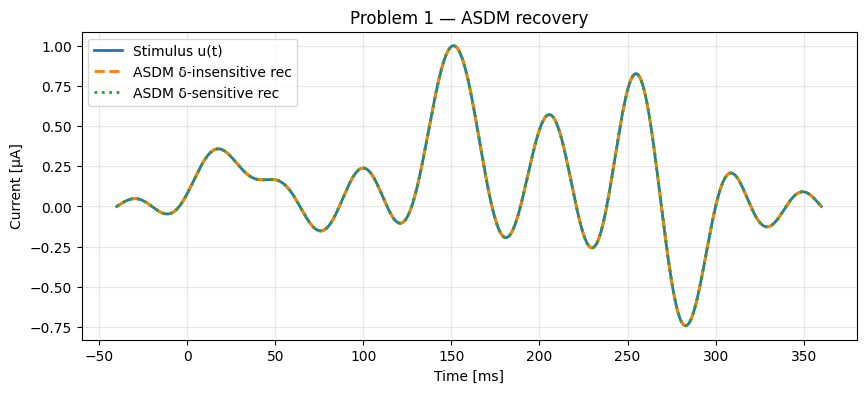

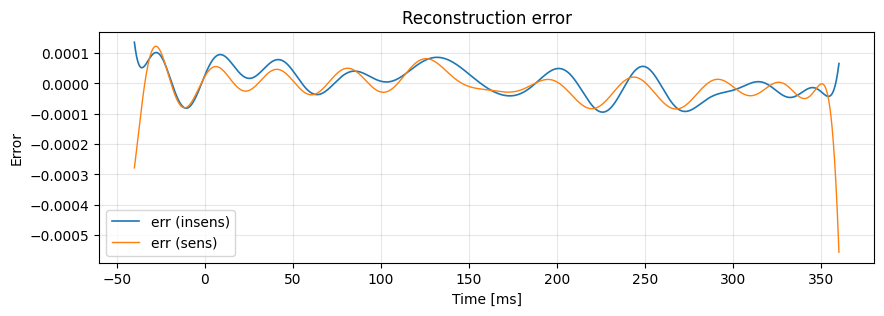

In [7]:
# TODO: Plot recovery (in the same plot with the original)

# we run both of the decoders now.
sign_for_q = -1  # This is the convention used in Chapter-06 in their ASDM decoder examples.
c_insens, u_rec_insens, K_est = asdm_decoder_insen(t, tk, asdm_params, sign=sign_for_q, rcond=1e-7)

#also compute to visually chec the differences now
c_sens, u_rec_sens = asdm_decoder_sen(t, tk, asdm_params, sign=sign_for_q, rcond=1e-7)

# quick sanity on the SNRs
def whole_signal_snr(u, urec):
    num = np.mean(u**2)
    den = np.mean((u - urec)**2)
    return 10*np.log10(num/den)
snr_ins = whole_signal_snr(u, u_rec_insens)
snr_sen = whole_signal_snr(u, u_rec_sens)
print("[PLOT SANITY] SNR_insens = {:.2f} dB | SNR_sensitive = {:.2f} dB".format(snr_ins, snr_sen))

#plotting
plt.figure(figsize=(10,4))
plt.plot(t*1e3, u, label='Stimulus u(t)', lw=2)
plt.plot(t*1e3, u_rec_insens, '--', label='ASDM δ-insensitive rec', lw=2)
plt.plot(t*1e3, u_rec_sens, ':', label='ASDM δ-sensitive rec', lw=2)
plt.xlabel('Time [ms]')
plt.ylabel('Current [μA]')
plt.title('Problem 1 — ASDM recovery')
plt.legend()
plt.grid(True, alpha=0.3)

# error overlay
plt.figure(figsize=(10,3))
plt.plot(t*1e3, u - u_rec_insens, label='err (insens)', lw=1.2)
plt.plot(t*1e3, u - u_rec_sens, label='err (sens)', lw=1.0)
plt.xlabel('Time [ms]')
plt.ylabel('Error')
plt.title('Reconstruction error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# If I could note that K_est may differ by a sign due to our 'sign_for_q' convention; so compare |K_est| to 2*kappa*delta.


### Part 2: Plot the recovery SNR

---



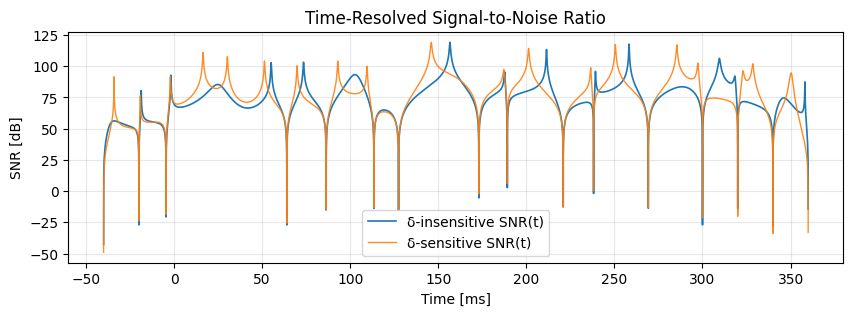

[SNR(t)] mean_ins=73.11 dB and the mean_sens=75.47 dB
[SNR(t)] min_ins=-42.65, max_ins=119.14


In [8]:
# Compute the SNR
# the SNR formula given in the question prompt is for whole-signal SNR
# which is a single value
# for SNR vs t plot use the function one below
eps = 1e-12

def SNR_f(u, u_rec):
    return 10 * np.log10((u**2 + eps) / ((u - u_rec)**2 + eps))

snr_t_ins = SNR_f(u, u_rec_insens)
snr_t_sen = SNR_f(u, u_rec_sens)

#plotting
plt.figure(figsize=(10,3))
plt.plot(t*1e3, snr_t_ins, label='δ-insensitive SNR(t)', lw=1.2)
plt.plot(t*1e3, snr_t_sen, label='δ-sensitive SNR(t)', lw=1.0, alpha=0.9)
plt.xlabel('Time [ms]')
plt.ylabel('SNR [dB]')
plt.title('Time-Resolved Signal-to-Noise Ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# summary stats
print(f"[SNR(t)] mean_ins={np.mean(snr_t_ins):.2f} dB and the mean_sens={np.mean(snr_t_sen):.2f} dB")
print(f"[SNR(t)] min_ins={np.min(snr_t_ins):.2f}, max_ins={np.max(snr_t_ins):.2f}")

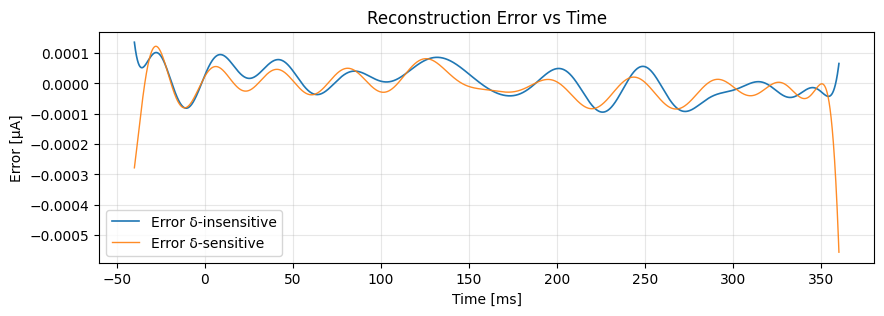

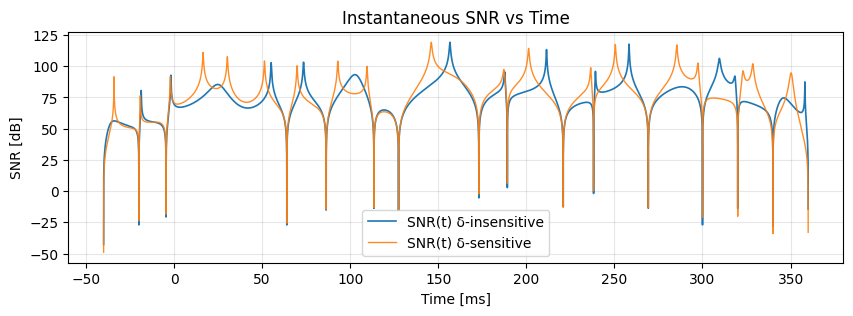

[SUMMARY] mean SNR_insens = 73.11 dB / mean SNR_sens = 75.47 dB
[SUMMARY] whole-signal SNR_insens = 77.01 dB / whole-signal SNR_sens = 75.84 dB


In [9]:
# TODO: plot the error and SNR as function of time

eps = 1e-12

def SNR_f(u, u_rec):
    """Instantaneous and the time resolved SNR"""
    return 10 * np.log10((u**2 + eps) / ((u - u_rec)**2 + eps))

#  error and the SNR(t) for both of the decoders we ahve
err_ins = u - u_rec_insens
err_sen = u - u_rec_sens
snr_t_ins = SNR_f(u, u_rec_insens)
snr_t_sen = SNR_f(u, u_rec_sens)

# Plot error
plt.figure(figsize=(10,3))
plt.plot(t*1e3, err_ins, label='Error δ-insensitive', lw=1.2)
plt.plot(t*1e3, err_sen, label='Error δ-sensitive', lw=1.0, alpha=0.9)
plt.xlabel('Time [ms]')
plt.ylabel('Error [μA]')
plt.title('Reconstruction Error vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Plot SNR(t
plt.figure(figsize=(10,3))
plt.plot(t*1e3, snr_t_ins, label='SNR(t) δ-insensitive', lw=1.2)
plt.plot(t*1e3, snr_t_sen, label='SNR(t) δ-sensitive', lw=1.0, alpha=0.9)
plt.xlabel('Time [ms]')
plt.ylabel('SNR [dB]')
plt.title('Instantaneous SNR vs Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# stats sanity
print(f"[SUMMARY] mean SNR_insens = {np.mean(snr_t_ins):.2f} dB / mean SNR_sens = {np.mean(snr_t_sen):.2f} dB")
print(f"[SUMMARY] whole-signal SNR_insens = {snr_ins:.2f} dB / whole-signal SNR_sens = {snr_sen:.2f} dB")

### Part 3: Compare the $\delta$-insensitive recovery result with the $\delta$-sensitive result

In [10]:
# TODO: implement delta-sensitive case (hopefully you did above already)

# Chapter6 we can see the ASDM delta-sensitive q_l = sign*(-1)^l*(2*kappa*delta - b*Δt_l))
sign_for_q = -1  # so we use the same sign convention used earlier / in Chapter-06

# Make suer that were gpomg tp have spike times from Cell 5
assert 'tk' in globals() and len(tk) > 1, "Run Cells 4–5 first to generate tk."

c_sens, u_rec_sens = asdm_decoder_sen(t, tk, asdm_params, sign=sign_for_q, rcond=1e-7)

#  sanity
print("[CELL10] c_sens shape:", c_sens.shape, "| ||c_sens||2={:.4g}".format(float(np.linalg.norm(c_sens))))
print("[CELL10] u_rec_sens stats: min={:.4g}, max={:.4g}, mean={:.4g}".format(
    float(np.min(u_rec_sens)), float(np.max(u_rec_sens)), float(np.mean(u_rec_sens))
))


[q-SENS] uses kappa*delta and b; shape: (115,) | first 3 entries: [9.40e-05 1.26e-04 1.53e-04]
[G] shape: (115, 115) | cond(G)~ 2.239e+17
[DEC-SENS] c shape: (115,) | ||c||2=0.698
[DEC-SENS] u_rec stats: min=-0.7419, max=1
[CELL10] c_sens shape: (115,) | ||c_sens||2=0.698
[CELL10] u_rec_sens stats: min=-0.7419, max=1, mean=0.1284


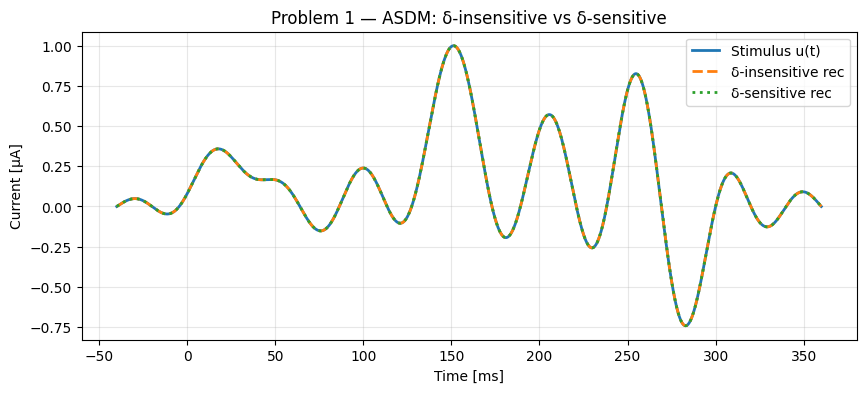

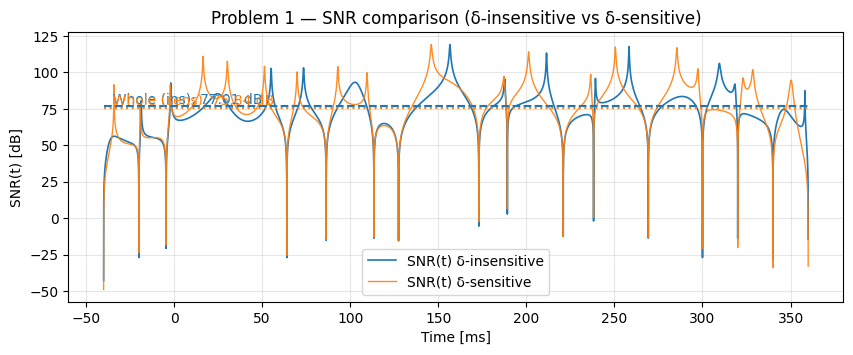

[CELL11] Whole-signal SNRs  |  δ-insens: 77.01 dB   δ-sens: 75.84 dB
[CELL11] SNR(t) ranges      |  ins: [-42.65, 119.14] dB   sens: [-48.89, 119.22] dB
[CELL11] Recon err (ins) stats: min=-9.466e-05, mean=5.127e-06, max=1.357e-04
[CELL11] Recon err (sens) stats: min=-5.562e-04, mean=-1.081e-05, max=1.223e-04


In [11]:
# TODO: Compare between sensitive and insensitive,
# plot both outputs in same plot with original
# (make use of legends and labels, feel free to adjust linewidth)

# plot both of the SNR in the same plot

# Ensure that the δ-insensitive reconstruction does exists (from Cells 6–7).
if 'u_rec_insens' not in globals():
    print("[CELL11] δ-insensitive reconstruction not found—computing now...")
    sign_for_q = -1
    c_insens, u_rec_insens, K_est = asdm_decoder_insen(t, tk, asdm_params, sign=sign_for_q, rcond=1e-7)

# same thing make sure it exsits but with the δ sensitive
if 'u_rec_sens' not in globals():
    print("[CELL11] δ-sensitive reconstruction not found—computing now...")
    sign_for_q = -1
    c_sens, u_rec_sens = asdm_decoder_sen(t, tk, asdm_params, sign=sign_for_q, rcond=1e-7)

# whole signal SNR for the prompt
def whole_signal_snr(u, urec, eps=1e-12):
    num = np.mean(u**2)
    den = np.mean((u - urec)**2) + eps
    return 10.0 * np.log10(num / den)

#compute SNRs
snr_whole_ins = whole_signal_snr(u, u_rec_insens)
snr_whole_sen = whole_signal_snr(u, u_rec_sens)

# finding the instant SNR(t) by using function from Cell 8
snr_t_ins = SNR_f(u, u_rec_insens)
snr_t_sen = SNR_f(u, u_rec_sens)

# the waveform comparison
plt.figure(figsize=(10, 4))
plt.plot(t*1e3, u,               label='Stimulus u(t)',        lw=2)
plt.plot(t*1e3, u_rec_insens, '--', label='δ-insensitive rec',   lw=2)
plt.plot(t*1e3, u_rec_sens,   ':', label='δ-sensitive rec',     lw=2)
plt.xlabel('Time [ms]')
plt.ylabel('Current [μA]')
plt.title('Problem 1 — ASDM: δ-insensitive vs δ-sensitive')
plt.legend()
plt.grid(True, alpha=0.3)

#snr comparison
plt.figure(figsize=(10, 3.5))
plt.plot(t*1e3, snr_t_ins, label='SNR(t) δ-insensitive', lw=1.2)
plt.plot(t*1e3, snr_t_sen, label='SNR(t) δ-sensitive',   lw=1.0, alpha=0.9)
# annotate the whooel signal snr
plt.hlines([snr_whole_ins, snr_whole_sen], xmin=t[0]*1e3, xmax=t[-1]*1e3,
           linestyles=['dashed','dotted'], colors=['C0','C1'])
plt.text(t[0]*1e3, snr_whole_ins, f'  Whole (ins): {snr_whole_ins:.2f} dB', va='bottom', color='C0')
plt.text(t[0]*1e3, snr_whole_sen, f'  Whole (sens): {snr_whole_sen:.2f} dB', va='bottom', color='C1')
plt.xlabel('Time [ms]')
plt.ylabel('SNR(t) [dB]')
plt.title('Problem 1 — SNR comparison (δ-insensitive vs δ-sensitive)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# more sanity checking
print("[CELL11] Whole-signal SNRs  |  δ-insens: {:.2f} dB   δ-sens: {:.2f} dB".format(
    snr_whole_ins, snr_whole_sen))
print("[CELL11] SNR(t) ranges      |  ins: [{:.2f}, {:.2f}] dB   sens: [{:.2f}, {:.2f}] dB".format(
    float(np.nanmin(snr_t_ins)), float(np.nanmax(snr_t_ins)),
    float(np.nanmin(snr_t_sen)), float(np.nanmax(snr_t_sen))
))
print("[CELL11] Recon err (ins) stats: min={:.3e}, mean={:.3e}, max={:.3e}".format(
    float(np.min(u - u_rec_insens)), float(np.mean(u - u_rec_insens)), float(np.max(u - u_rec_insens))
))
print("[CELL11] Recon err (sens) stats: min={:.3e}, mean={:.3e}, max={:.3e}".format(
    float(np.min(u - u_rec_sens)), float(np.mean(u - u_rec_sens)), float(np.max(u - u_rec_sens))
))


# Problem 2

In [12]:
# Import libraries
%matplotlib inline
import numpy as np
import typing as tp
from scipy import signal
from scipy.linalg import circulant
from scipy.integrate import quad
from scipy.integrate import cumulative_trapezoid as cumtrapz
from compneuro.utils.phase_response import PIF, iPRC
from compneuro.utils.neuron import limit_cycle
from compneuro.utils.signal import spike_detect, spike_detect_local
from compneuro.utils.signal import convolve
import matplotlib.pyplot as plt

np.random.seed(0)  # fix random seed
from tqdm.notebook import tqdm

plt.rcParams["figure.figsize"] = [12, 3]
plt.rcParams["figure.dpi"] = 100

In [13]:
iaf_params = dict(
    kappa = 1, # mF
    delta = 0.01,  # mV
    b = 1,
    omega = omega
)

# TODO: implement IAF and TEM encoding
def iaf_encode(u, iaf_params):
    """
    [[[[Andre]]] now were take the Ideal IAF encoding that we found in Chapter 6, Sec. 6.2:
      y[i] = y[i-1] + dt * ( b + 0.5*(u[i] + u[i-1]) ) / kappa
    which happens when y crosses +delta, then emit a spike at t[i] and reset y -> 0.

    Going to return

    tk : np.ndarray
        Spike times.
    tk_idx : list[int]
        And then the indices into the global time grid t for those spikes.
    """
    kappa = iaf_params["kappa"]
    delta = iaf_params["delta"]
    b     = iaf_params["b"]

    assert 't' in globals() and 'dt' in globals(), "Run the cell that defines t and dt first."
    n = len(t)

    y = np.zeros(n)
    tk_idx = []

    for i in range(1, n):
        # integrate biased stimulus (trapezoidal in u)
        y[i] = y[i-1] + dt * (b + 0.5 * (u[i] + u[i-1])) / kappa

        # threshold crossing → spike, reset to 0
        if y[i] >= delta:
            tk_idx.append(i)
            y[i] = 0.0

    tk = t[tk_idx]

    #sanity printouts
    print("[IAF ENCODE] spikes:", len(tk_idx))
    if len(tk_idx) > 1:
        isi = np.diff(tk)
        print("[IAF ENCODE] ISI stats (s): min={:.6g}, mean={:.6g}, max={:.6g}".format(
            float(np.min(isi)), float(np.mean(isi)), float(np.max(isi))))
        print("[IAF ENCODE] Nyquist interval T = {:.6g} s; frac(ISI<T): {:.2%}".format(
            np.pi/iaf_params["omega"], np.mean(isi < (np.pi/iaf_params["omega"])) ))
    else:
        print("[IAF ENCODE] Not enough spikes to compute ISIs.")
    print("[IAF ENCODE] y-range after resets: [{:.4g}, {:.4g}] (threshold≈{:.4g})".format(
        float(np.min(y)), float(np.max(y)), delta))

    return tk, tk_idx
tk_iaf, tk_idx_iaf = iaf_encode(u, iaf_params)


[IAF ENCODE] spikes: 45
[IAF ENCODE] ISI stats (s): min=0.005059, mean=0.00884045, max=0.017568
[IAF ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 100.00%
[IAF ENCODE] y-range after resets: [0, 0.01] (threshold≈0.01)


In [14]:
# TODO: implement TDM recovery


def compute_G(t, tk, omega=None):
    """
    not in chapter but now build G_{l,k} = ∫_{t_l}^{t_{l+1}} g(s - s_k) ds
    which is using the sinc_basis (which tries to return g just with the proper scaling).
    """
    if omega is None:
        #  ambient omega that was defined earlier
        assert 'omega' in globals(), "omega must be provided or exist globally."
        omega = globals()['omega']

    dt_local = t[1] - t[0]
    # the spike midpointss
    sk = 0.5 * (tk[1:] + tk[:-1])

    # should map the spike times back to the indices on a uniform grid
    def _safe_tk_indices(t, tk):
        idx = np.searchsorted(t, tk)
        idx = np.clip(idx, 0, len(t)-1)
        idx2 = np.clip(idx-1, 0, len(t)-1)
        # this  the correct potential off-by-one due to it being a float
        ok_mask = np.isclose(t[idx], tk, atol=0, rtol=0)
        idx[~ok_mask] = idx2[~ok_mask]
        assert np.allclose(t[idx], tk, atol=0, rtol=0), "Spike times must lie on grid t."
        return idx

    tk_id = _safe_tk_indices(t, tk)

    L = len(tk) - 1
    G = np.zeros((L, L))
    for k, s_k in enumerate(sk):
        gk = sinc_basis(t, s_k, omega)           # g(t - s_k)
        csum = cumtrapz(gk, dx=dt_local, initial=0.0)  # ∫ g
        G[:, k] = np.diff(csum[tk_id])           # ∫_{t_l}^{t_{l+1}} g
    # diag. sanity
    if G.shape[0] == G.shape[1]:
        try:
            print("[IAF G] shape:", G.shape, "| cond(G)≈", "{:.3e}".format(np.linalg.cond(G)))
        except np.linalg.LinAlgError:
            print("[IAF G] shape:", G.shape, "| cond(G)=nan (LinAlgError)")
    else:
        print("[IAF G] shape:", G.shape)
    return G


def compute_q(tk, iaf_params):
    """
    Now the IAF t-transform: ∫_{t_k}^{t_{k+1}} u(s) ds = kappa*delta - b * Δt_k
    Should builds the 'q' vector directly from the spike times (that are threshold-sensitive).
    """
    kappa = iaf_params["kappa"]
    delta = iaf_params["delta"]
    b     = iaf_params["b"]

    dtk = np.diff(tk)
    q = kappa * delta - b * dtk
    print("[IAF q] shape:", q.shape, "| first 3:", q[:3] if len(q) >= 3 else q)
    return q


def iaf_decode(t, tk, iaf_params, omega=None, rcond=1e-7):
    if omega is None:
        assert 'omega' in globals(), "omega must be provided or exist globally."
        omega = globals()['omega']

    if len(tk) < 2:
        raise ValueError("2 spikes to decode.")

    # NOW build q and G
    q = compute_q(tk, iaf_params)
    G = compute_G(t, tk, omega=omega)

    # then solve for coefficients
    c = np.linalg.pinv(G, rcond=rcond) @ q

    # now reconstruct with sinc basis at midpoints s_k
    sk = 0.5 * (tk[1:] + tk[:-1])
    u_rec = c @ sinc_basis(t, sk, omega)

    # sanity print
    resid = np.linalg.norm(q - G @ c)
    print("[IAF DEC] ||q - Gc||₂ = {:.3e}".format(float(resid)))
    print("[IAF DEC] ||c||₂ = {:.4g}".format(float(np.linalg.norm(c))))
    print("[IAF DEC] u_rec stats: min={:.4g}, max={:.4g}".format(float(np.min(u_rec)), float(np.max(u_rec))))

    return c, u_rec

tk_iaf, tk_idx_iaf = iaf_encode(u, iaf_params)
c_iaf, uhat = iaf_decode(t, tk_iaf, iaf_params)



[IAF ENCODE] spikes: 45
[IAF ENCODE] ISI stats (s): min=0.005059, mean=0.00884045, max=0.017568
[IAF ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 100.00%
[IAF ENCODE] y-range after resets: [0, 0.01] (threshold≈0.01)
[IAF q] shape: (44,) | first 3: [ 3.32e-04 -3.02e-04 -2.00e-05]
[IAF G] shape: (44, 44) | cond(G)≈ 4.867e+15
[IAF DEC] ||q - Gc||₂ = 1.337e-06
[IAF DEC] ||c||₂ = 2.389
[IAF DEC] u_rec stats: min=-0.7419, max=0.9997


In [15]:
# on off separation
u_on = np.clip(u, 0, u.max())
u_off = -1*np.clip(u, u.min(), 0)

In [16]:
# TODO: encode and decode with b=1

iaf_params_1 = dict(
    kappa = 1, # mF
    delta = 0.01,  # mV
    b = 1,
    omega = omega
)

# TODO: encode and decode with b=1
# the correct ON/OFF split
u_on  = np.clip(u, 0, None)
u_off = np.clip(-u, 0, None)

iaf_params_1 = dict(kappa=1.0, delta=0.01, b=1.0, omega=omega)

# This is the baseline (no separation):
tk_u, _      = iaf_encode(u, iaf_params_1)
c_u, u_hat   = iaf_decode(t, tk_u, iaf_params_1)

#ON channel: u_on → û_on
tk_on, _     = iaf_encode(u_on, iaf_params_1)
c_on, uhat_on = iaf_decode(t, tk_on, iaf_params_1)

# OFF channel: u_off → û_off
tk_off, _     = iaf_encode(u_off, iaf_params_1)
c_off, uhat_off = iaf_decode(t, tk_off, iaf_params_1)

# now for the combined ON–OFF reconstruction
uhat_onoff = uhat_on - uhat_off

def whole_signal_snr(u_true, u_rec):
    num = np.mean(u_true**2); den = np.mean((u_true - u_rec)**2) + 1e-20
    return 10*np.log10(num/den)

print(f"[b=1] SNR(û)        = {whole_signal_snr(u, u_hat):.2f} dB")
print(f"[b=1] SNR(û_on)     = {whole_signal_snr(u_on, uhat_on):.2f} dB")
print(f"[b=1] SNR(û_off)    = {whole_signal_snr(u_off, uhat_off):.2f} dB")
print(f"[b=1] SNR(û_onoff)  = {whole_signal_snr(u, uhat_onoff):.2f} dB")

[IAF ENCODE] spikes: 45
[IAF ENCODE] ISI stats (s): min=0.005059, mean=0.00884045, max=0.017568
[IAF ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 100.00%
[IAF ENCODE] y-range after resets: [0, 0.01] (threshold≈0.01)
[IAF q] shape: (44,) | first 3: [ 3.32e-04 -3.02e-04 -2.00e-05]
[IAF G] shape: (44, 44) | cond(G)≈ 4.867e+15
[IAF DEC] ||q - Gc||₂ = 1.337e-06
[IAF DEC] ||c||₂ = 2.389
[IAF DEC] u_rec stats: min=-0.7419, max=0.9997
[IAF ENCODE] spikes: 47
[IAF ENCODE] ISI stats (s): min=0.005027, mean=0.00836833, max=0.010001
[IAF ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 100.00%
[IAF ENCODE] y-range after resets: [0, 0.01] (threshold≈0.01)
[IAF q] shape: (46,) | first 3: [3.3200000e-04 9.9999999e-07 1.1600000e-04]
[IAF G] shape: (46, 46) | cond(G)≈ 4.283e+16
[IAF DEC] ||q - Gc||₂ = 2.040e-03
[IAF DEC] ||c||₂ = 255
[IAF DEC] u_rec stats: min=-1.848, max=0.982
[IAF ENCODE] spikes: 42
[IAF ENCODE] ISI stats (s): min=0.005832, mean=0.00941034, max=0.010001
[IAF ENCODE] Nyquist int

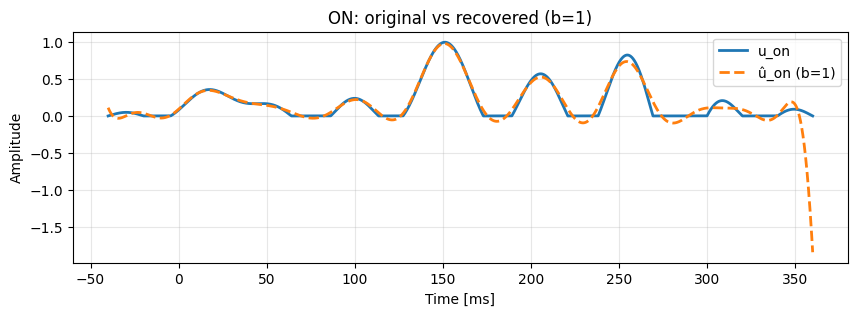

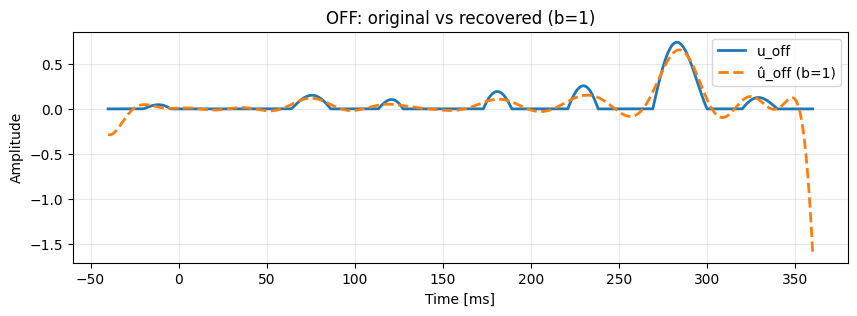

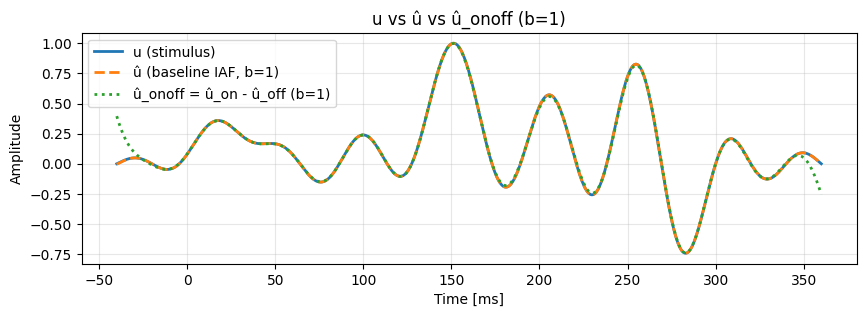

In [17]:
# TODO: plot the waveforms

plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, u_on, label='u_on', lw=2)
plt.plot(t * 1e3, uhat_on, '--', label='û_on (b=1)', lw=2)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('ON: original vs recovered (b=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, u_off, label='u_off', lw=2)
plt.plot(t * 1e3, uhat_off, '--', label='û_off (b=1)', lw=2)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('OFF: original vs recovered (b=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, u, label='u (stimulus)', lw=2)
plt.plot(t * 1e3, u_hat, '--', label='û (baseline IAF, b=1)', lw=2)
plt.plot(t * 1e3, uhat_onoff, ':', label='û_onoff = û_on - û_off (b=1)', lw=2)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('u vs û vs û_onoff (b=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

[b=1] Whole-signal SNRs:
  SNR(û)        = 59.25 dB
  SNR(û_on)     = 7.41 dB
  SNR(û_off)    = 2.14 dB
  SNR(û_onoff)  = 18.68 dB


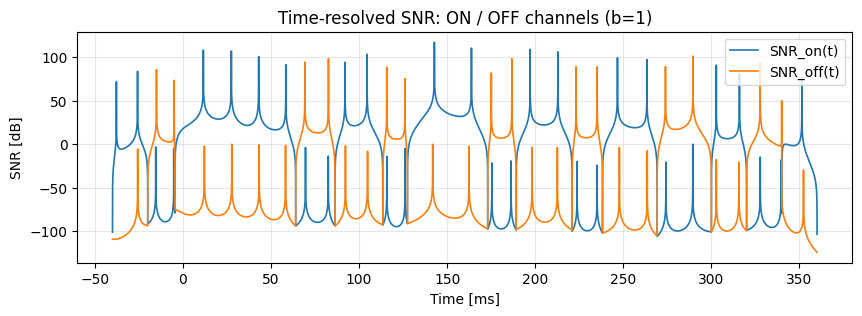

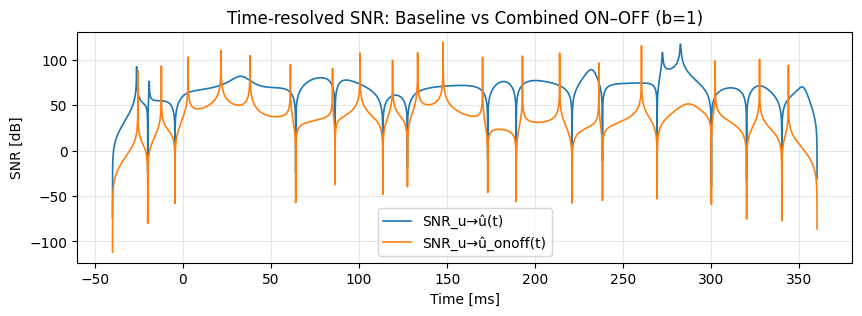

In [18]:
# TODO: plot the SNRs

# helper
def SNR_f(u, u_rec):
    eps = 1e-12
    return 10 * np.log10((u**2 + eps) / ((u - u_rec)**2 + eps))

# Should be the whole-signal SNR values just restated
snr_u        = whole_signal_snr(u, u_hat)
snr_on       = whole_signal_snr(u_on, uhat_on)
snr_off      = whole_signal_snr(u_off, uhat_off)
snr_onoff    = whole_signal_snr(u, uhat_onoff)

print(f"[b=1] Whole-signal SNRs:")
print(f"  SNR(û)        = {snr_u:.2f} dB")
print(f"  SNR(û_on)     = {snr_on:.2f} dB")
print(f"  SNR(û_off)    = {snr_off:.2f} dB")
print(f"  SNR(û_onoff)  = {snr_onoff:.2f} dB")

# Here we see the time-resolved SNRs
snr_t_u      = SNR_f(u, u_hat)
snr_t_on     = SNR_f(u_on, uhat_on)
snr_t_off    = SNR_f(u_off, uhat_off)
snr_t_onoff  = SNR_f(u, uhat_onoff)

# Plotting
plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, snr_t_on,  label='SNR_on(t)',  lw=1.2)
plt.plot(t * 1e3, snr_t_off, label='SNR_off(t)', lw=1.2)
plt.xlabel('Time [ms]'); plt.ylabel('SNR [dB]')
plt.title('Time-resolved SNR: ON / OFF channels (b=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, snr_t_u,     label='SNR_u→û(t)', lw=1.2)
plt.plot(t * 1e3, snr_t_onoff, label='SNR_u→û_onoff(t)', lw=1.2)
plt.xlabel('Time [ms]'); plt.ylabel('SNR [dB]')
plt.title('Time-resolved SNR: Baseline vs Combined ON–OFF (b=1)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [19]:
iaf_params_2 = dict(
    kappa = 1, # mF
    delta = 0.01,  # mV
    b = 0.2,
    omega = omega
)

# TODO: encode and decode with b=0.2

#same ON/OFF split from before
u_on  = np.clip(u, 0, None)
u_off = np.clip(-u, 0, None)

iaf_params_2 = dict(kappa=1.0, delta=0.01, b=0.2, omega=omega)

# Here we have the baseline (no separation): u → û
tk_u2, _        = iaf_encode(u, iaf_params_2)
c_u2, u_hat2    = iaf_decode(t, tk_u2, iaf_params_2)

#on
tk_on2, _       = iaf_encode(u_on, iaf_params_2)
c_on2, uhat_on2 = iaf_decode(t, tk_on2, iaf_params_2)
#off
tk_off2, _        = iaf_encode(u_off, iaf_params_2)
c_off2, uhat_off2 = iaf_decode(t, tk_off2, iaf_params_2)

uhat_onoff2 = uhat_on2 - uhat_off2

def whole_signal_snr(u_true, u_rec):
    num = np.mean(u_true**2)
    den = np.mean((u_true - u_rec)**2) + 1e-20
    return 10*np.log10(num/den)

print(f"[b=0.2] SNR(û)        = {whole_signal_snr(u, u_hat2):.2f} dB")
print(f"[b=0.2] SNR(û_on)     = {whole_signal_snr(u_on, uhat_on2):.2f} dB")
print(f"[b=0.2] SNR(û_off)    = {whole_signal_snr(u_off, uhat_off2):.2f} dB")
print(f"[b=0.2] SNR(û_onoff)  = {whole_signal_snr(u, uhat_onoff2):.2f} dB")



[IAF ENCODE] spikes: 13
[IAF ENCODE] ISI stats (s): min=0.008509, mean=0.0291066, max=0.093934
[IAF ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 50.00%
[IAF ENCODE] y-range after resets: [-0.003243, 0.01] (threshold≈0.01)
[IAF q] shape: (12,) | first 3: [0.0061152 0.0050608 0.0005996]
[IAF G] shape: (12, 12) | cond(G)≈ 3.492e+01
[IAF DEC] ||q - Gc||₂ = 6.186e-17
[IAF DEC] ||c||₂ = 0.03157
[IAF DEC] u_rec stats: min=-0.6209, max=1.005
[IAF ENCODE] spikes: 15
[IAF ENCODE] ISI stats (s): min=0.008962, mean=0.0238789, max=0.040555
[IAF ENCODE] Nyquist interval T = 0.02 s; frac(ISI<T): 35.71%
[IAF ENCODE] y-range after resets: [0, 0.01] (threshold≈0.01)
[IAF q] shape: (14,) | first 3: [0.0060472 0.0051352 0.001889 ]
[IAF G] shape: (14, 14) | cond(G)≈ 2.273e+01
[IAF DEC] ||q - Gc||₂ = 2.612e-17
[IAF DEC] ||c||₂ = 0.02666
[IAF DEC] u_rec stats: min=-0.24, max=0.997
[IAF ENCODE] spikes: 10
[IAF ENCODE] ISI stats (s): min=0.014424, mean=0.0368176, max=0.05
[IAF ENCODE] Nyquist interval T =

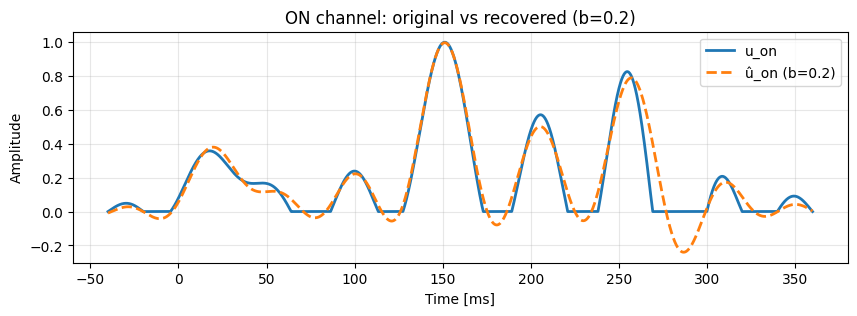

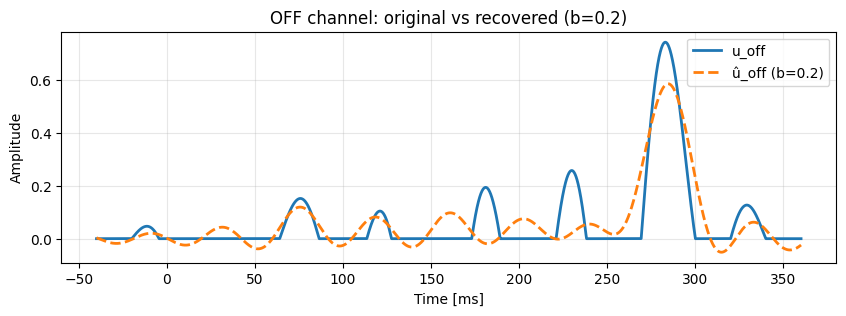

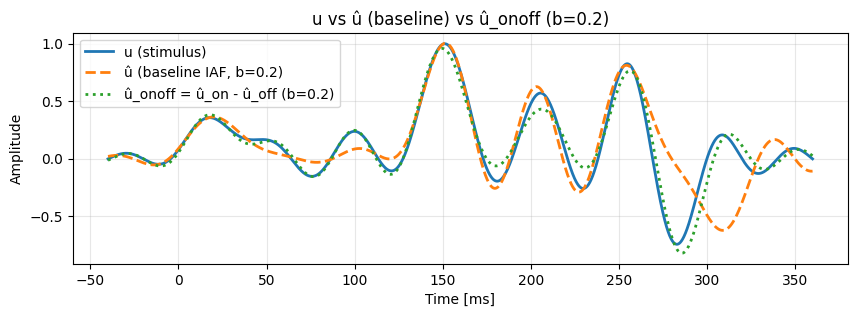

In [20]:
# TODO: plot the waveforms

#on original vs recovered
plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, u_on, label='u_on', lw=2)
plt.plot(t * 1e3, uhat_on2, '--', label='û_on (b=0.2)', lw=2)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('ON channel: original vs recovered (b=0.2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

#off original vs recovered
plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, u_off, label='u_off', lw=2)
plt.plot(t * 1e3, uhat_off2, '--', label='û_off (b=0.2)', lw=2)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('OFF channel: original vs recovered (b=0.2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

#this will be u vs baseline
plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, u, label='u (stimulus)', lw=2)
plt.plot(t * 1e3, u_hat2, '--', label='û (baseline IAF, b=0.2)', lw=2)
plt.plot(t * 1e3, uhat_onoff2, ':', label='û_onoff = û_on - û_off (b=0.2)', lw=2)
plt.xlabel('Time [ms]'); plt.ylabel('Amplitude')
plt.title('u vs û (baseline) vs û_onoff (b=0.2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

[b=0.2] Whole-signal SNRs:
  SNR(û)        = 3.88 dB
  SNR(û_on)     = 12.72 dB
  SNR(û_off)    = 6.41 dB
  SNR(û_onoff)  = 13.24 dB


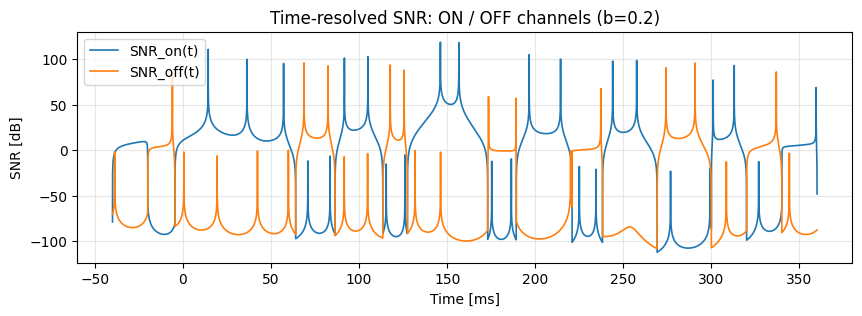

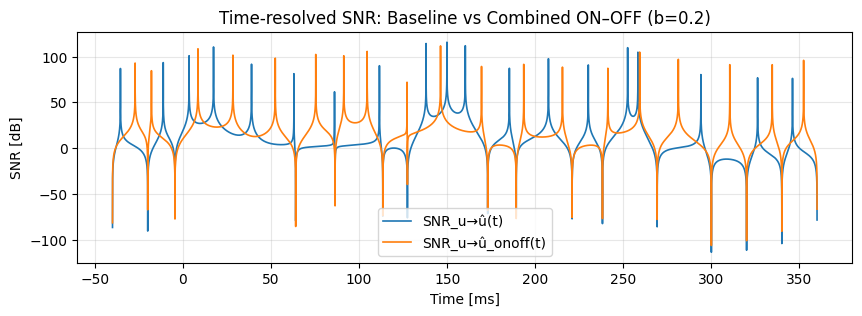

In [21]:
# TODO: plot the SNRs

# helpers
def SNR_f(u, u_rec):
    eps = 1e-12
    return 10 * np.log10((u**2 + eps) / ((u - u_rec)**2 + eps))

snr_u2        = whole_signal_snr(u, u_hat2)
snr_on2       = whole_signal_snr(u_on, uhat_on2)
snr_off2      = whole_signal_snr(u_off, uhat_off2)
snr_onoff2    = whole_signal_snr(u, uhat_onoff2)

print(f"[b=0.2] Whole-signal SNRs:")
print(f"  SNR(û)        = {snr_u2:.2f} dB")
print(f"  SNR(û_on)     = {snr_on2:.2f} dB")
print(f"  SNR(û_off)    = {snr_off2:.2f} dB")
print(f"  SNR(û_onoff)  = {snr_onoff2:.2f} dB")

#  Here we have the time-resolved SNRs
snr_t_u2      = SNR_f(u, u_hat2)
snr_t_on2     = SNR_f(u_on, uhat_on2)
snr_t_off2    = SNR_f(u_off, uhat_off2)
snr_t_onoff2  = SNR_f(u, uhat_onoff2)

#  Now we can plot the time-resolved SNRs
plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, snr_t_on2,  label='SNR_on(t)',  lw=1.2)
plt.plot(t * 1e3, snr_t_off2, label='SNR_off(t)', lw=1.2)
plt.xlabel('Time [ms]'); plt.ylabel('SNR [dB]')
plt.title('Time-resolved SNR: ON / OFF channels (b=0.2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(t * 1e3, snr_t_u2,     label='SNR_u→û(t)', lw=1.2)
plt.plot(t * 1e3, snr_t_onoff2, label='SNR_u→û_onoff(t)', lw=1.2)
plt.xlabel('Time [ms]'); plt.ylabel('SNR [dB]')
plt.title('Time-resolved SNR: Baseline vs Combined ON–OFF (b=0.2)')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

When we were comparing the different reconstructions for the ON, the OFF, and the combined ON–OFF channels, we could observe that the combined signal $\hat{u}*{onoff}$ ended up consistently performing much better than either the $\hat{u}*{on}$ or the $\hat{u}*{off}$ when they were alone. Additionally, for $b = 1$, we could see that the SNRs for the ON and OFF channels were roughly around $7,\text{dB}$ and $2,\text{dB}$, while the combined $\hat{u}*{onoff}$ ended up reaching about $19,\text{dB}$. I would think that this makes some sense because the ON and the OFF neurons encode complementary halves of the stimulus (we know that one responds to positive excursions and the other one responds to the negative ones), so subtracting their reconstructions manages to recover missing portions of the waveform. However, the individual ON and OFF signals are half-wave rectified, which introduces some discontinuities, and we start to see some of those high-frequency artifacts that the $\delta$-sensitive decoder cannot seem to perfectly capture. Something like this is visible in the $SNR(t)$ plots, where both channels show sharp dips around zero crossings, and also in the waveform plots, where the reconstructions happen to slightly overshoot near the transitions. As a result, even though the combined ON and OFF signal manages to improve upon some of the individual components, it actually still falls far short of the baseline bandlimited IAF reconstruction ($\mathrm{SNR} = 59.25,\text{dB}$), which then benefits from the higher spike density and a perfectly monotonic integrator.

Next, for $b = 0.2$, we can start to see the results change dramatically. First, the baseline IAF reconstruction drops to only about $3.9,\text{dB}$ since the low bias causes the neuron to fire a little less frequently, which then leads to large inter-spike intervals (many of which end up exceeding the Nyquist limit) and effectively undersampling the input. In contrast, we see that the ON and the OFF channels now each integrate monotonically within their nonnegative ranges, which would then better fit the IAF model assumptions. The ON channel gets an SNR of roughly $12.7,\text{dB}$, and the OFF channel about $6.4,\text{dB}$, and the combined ON–OFF reconstruction manages to improve slightly further to $13.2,\text{dB}$. It seems that this improvement is also reflected in the $SNR(t)$ curves, where the ON channel consistently outperforms the OFF channel, and the combined signal closely tracks ON’s behavior. Thus, while the rectification introduces its own distortions, it partially compensates for the loss of monotonicity that occurs when $b$ is too small.

It seems that overall, these results illustrate that a higher bias current is going to produce a denser, more uniform spiking that enables accurate reconstruction for the entire bandlimited signal, whereas a lower bias would mean sparse, uneven firing that could violate the IAF decoder’s assumptions. In such cases, separating the signal into ON and OFF components can help to restore monotonic integration and help recover information, eventually improving SNR. Even in these instances, however, the performance cannot fully match the ideal high-bias case.

### Miscellaneous (attention)
* please remember to include your name in the corresponding field at the start of this notebook, otherwize an automatic 0 grade will be received for any missing member
* please submit one copy per team
* please clearly present your solutions and answers with proper use of plots, markdown and comments
* please start the assignment as soon as possible, submission deadlines are strictly followed and late submissions after we posted the solution (ususlly on the same day as the deadline) will receive automatic 0
* please email both TAs at least 48hrs ahead of deadline if you cannot submit an assignment on time (due to exam schedules or  overwhelming deadlines, etc), we are flexible as long as we are informed
* please post your questions on Ed Discussions, and attend the office hours (every Thursday evening); **more on Ed**:
    * while discussing on Ed, please make good use of the reply and comment features inside threads to avoid cluttering with multiple threads regarding the same question from the same user
    * please refrain from asking questions or posting threads that would explicitly share the right answer with everyone
    * only post code snipets when you have narrowed down the issue to that particular section and only share ploted results only when you have good reason to suspect their correctness
    * once you finish debugging your code by the end of a thread, please avoid languages such as "is this correct now?" since we aren't really allowed to explicitly say yes when they are; be confident in your hardwork.